In [1]:
!pip install tensorflow==2.10
!pip install image-classifiers==0.2.2
!pip install segmentation-models
!pip install psutil

ERROR: Could not find a version that satisfies the requirement tensorflow==2.10 (from versions: 2.12.0rc0, 2.12.0rc1, 2.12.0, 2.12.1, 2.13.0rc0, 2.13.0rc1, 2.13.0rc2, 2.13.0, 2.13.1, 2.14.0rc0, 2.14.0rc1, 2.14.0, 2.14.1, 2.15.0rc0, 2.15.0rc1, 2.15.0, 2.15.1, 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.10


  Using cached image_classifiers-0.2.2-py2.py3-none-any.whl.metadata (8.3 kB)
Using cached image_classifiers-0.2.2-py2.py3-none-any.whl (72 kB)
  Attempting uninstall: image-classifiers
    Found existing installation: image-classifiers 1.0.0
    Uninstalling image-classifiers-1.0.0:
      Successfully uninstalled image-classifiers-1.0.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models 1.0.1 requires image-classifiers==1.0.0, but you have image-classifiers 0.2.2 which is incompatible.


  Using cached image_classifiers-1.0.0-py3-none-any.whl.metadata (8.6 kB)
Using cached image_classifiers-1.0.0-py3-none-any.whl (19 kB)
  Attempting uninstall: image-classifiers
    Found existing installation: image-classifiers 0.2.2
    Uninstalling image-classifiers-0.2.2:
      Successfully uninstalled image-classifiers-0.2.2


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

In [ ]:
# Pfad zu Ihrem Projektordner in Google Drive
project_path = '/content/drive/MyDrive/sisa-fork'

# Arbeitsverzeichnis wechseln
os.chdir(project_path)

print("Aktuelles Verzeichnis:", os.getcwd())

In [21]:

import json
import os
import csv
import time
import psutil
import re
import time
import threading
from collections import defaultdict
from datetime import datetime
from classification_models.keras import Classifiers
from tensorflow import keras
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tensorflow.keras.callbacks import (
    CSVLogger,
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
import subprocess
import sys
sys.path.append("C:/Users/sophi/OneDrive/Documents/TH/Bachelorarbeit/Code/notebooks/SISA/sisa-fork")
from datasets.CIFAR10.dataloader_all_data import load
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

TODO:
- Model laden + die Pytorch Impl anpassen -> DONE
- Datensaetze vorbereiten -> DONE
- Korrekte Argumente für Skripte -> DONE
- Validationdatensatz in Training, pruefen wie genutzt
- Extra Eval fuer Vergleichbarkeit
- Ausfuerhung in Colab moeglich machen -> Google Drive
- Datei für Unlearning nutzen


In [3]:
#Global Config
BATCH_SIZE = 64 #more balance for gradient updates
EPOCHS = 30
LEARNING_RATE = 0.001
IMAGE_SIZE = 32 # CIFAR-10 is 32x32, better resolution than with 64x64 ( no resizing noise)
NUM_CLASSES = 10

#initializes NumpY and Tenserflow to work deterministicaly
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

DATAFILEPATH= r"datasets/CIFAR10/datasetfile_all_data"
DATALOADER= "datasets.CIFAR10.dataloader_all_data"

DATAFILEPATH_UNLEARNING= r"datasets/CIFAR10/datasetfile_random10_deletion"
OPTIMIZER = "adam" # --optimizer adam

#SISA Specific
CONTAINER_NAME= "Baseline"
NUM_SHARDS = 10
NUM_SLICES = 5
MODEL_NAME="resnet18"
LABEL="0"

In [4]:
#Log what GPU is used in training -> Colab specific
!nvidia-smi

Der Befehl "nvidia-smi" ist entweder falsch geschrieben oder
konnte nicht gefunden werden.


In [46]:
# --- ResourceMonitor für externe Prozesse ---
class ExternalResourceMonitor:
    def __init__(self):
        self.total_training_time = 0
        self.max_ram_gb = 0
        self.gpu_available = torch.cuda.is_available()
        self.max_gpu_gb = 0
        self.ram_history = []
        self.gpu_history = []
        self.epoch_history = []
        self.accuracy_history = []
        self.val_accuracy_history = []
        self.start_time = None
        self.process = None
        self.stop_event = threading.Event()
        self.current_ram_gb = 0
        self.current_gpu_gb = 0

    def start(self):
        """Starte die Ressourcenüberwachung."""
        self.start_time = time.perf_counter()
        self.stop_event.clear()
        self.ram_history = []
        self.gpu_history = []
        self.accuracy_history = []
        self.val_accuracy_history = []
        if self.gpu_available:
            torch.cuda.reset_peak_memory_stats()

    def update(self):
        """Aktualisiere RAM/GPU-Nutzung."""
        # RAM
        ram_gb = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 3)
        self.ram_history.append(ram_gb)
        self.max_ram_gb = max(self.max_ram_gb, ram_gb)

        # GPU
        if self.gpu_available:
            try:
                gpu_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)
                self.current_gpu_gb = gpu_gb
                self.gpu_history.append(gpu_gb)
                self.max_gpu_gb = max(self.max_gpu_gb, gpu_gb)
                torch.cuda.reset_peak_memory_stats()
            except Exception as e:
                print(f"GPU-Messung fehlgeschlagen: {e}")

    def stop(self):
        """Beende die Ressourcenüberwachung."""
        if self.start_time is not None:
            self.total_training_time = time.perf_counter() - self.start_time
        self.stop_event.set()

    def parse_accuracy(self, line):
        """Extrahiere Accuracy-Werte aus der Ausgabe."""
        match = re.search(r"\b0\.\d{4}\b|\b1\.0\b", line)
        if match:
            accuracy = float(match.group(0))
            self.accuracy_history.append(accuracy)
            return True
        return False
        # Suche nach Train/Val Accuracy (z.B. "Train Accuracy: 0.85, Val Accuracy: 0.82")
        #match = re.search(r"Train Accuracy: (\d+\.\d+),?\s*Val Accuracy: (\d+\.\d+)", line)
        #if match:
            #self.accuracy_history.append(float(match.group(1)))
            #self.val_accuracy_history.append(float(match.group(2)))
            #return True
        # Suche nach nur Accuracy (z.B. "Accuracy: 0.85" oder "0.3532")
        #match = re.search(r"(?:Train|Val|Accuracy:?)\s*(\d+\.\d+)", line)
        #if match:
            #accuracy = float(match.group(1))
            # Falls nur eine Accuracy gefunden wird, füge sie zu train_accuracy hinzu
            #self.accuracy_history.append(accuracy)
            #return True
        #return False


    def read_stream(self, stream, stream_name):
        """Lese einen Stream (stdout oder stderr) in einem separaten Thread."""
        try:
            for line in iter(stream.readline, b''):
                if self.stop_event.is_set():
                    break
                line = line.decode('utf-8').strip()
                if line:
                    if stream_name == "stdout":
                        print(line)
                        self.update()
                        self.parse_accuracy(line)
                    else:
                        print(f"STDERR: {line}", file=sys.stderr)
                        self.update()  # Auch bei stderr Ressourcen aktualisieren
        except Exception as e:
            print(f"Fehler beim Lesen von {stream_name}: {e}", file=sys.stderr)

    def run_command(self, command, description="Schritt"):
        """Führe einen Befehl aus, überwache Ressourcen und zeige stdout/stderr in Echtzeit an."""
        print(f"\n{'='*50}\n{description}\n{'='*50}")

        self.start()
        self.process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=False,
            bufsize=1,
            universal_newlines=False
        )

        stdout_thread = threading.Thread(
            target=self.read_stream,
            args=(self.process.stdout, "stdout")
        )
        stderr_thread = threading.Thread(
            target=self.read_stream,
            args=(self.process.stderr, "stderr")
        )
        stdout_thread.start()
        stderr_thread.start()

        # Aktualisiere Ressourcen in der Hauptthread, während der Prozess läuft
        while self.process.poll() is None:
            self.update()
            time.sleep(0.1)  # Kurze Pause, um CPU zu schonen

        self.process.wait()
        self.stop()

        stdout_thread.join(timeout=1)
        stderr_thread.join(timeout=1)

        report = self.get_report()
        print(f"\nRessourcenbericht für '{description}':")
        for key, value in report.items():
            if isinstance(value, list):
                if value:
                    print(f"  - {key}: {len(value)} Werte (z. B. {value[:3]})")
                else:
                    print(f"  - {key}: 0 Werte")
            else:
                print(f"  - {key}: {value}")

        # Plotte nur, wenn Daten vorhanden sind
        if self.ram_history or self.gpu_history or self.accuracy_history:
            self.plot_usage(description)
        else:
            print("Keine Ressourcen- oder Accuracy-Daten zum Plotten verfügbar.")

        return self.process.returncode

    def get_report(self):
        """Erstelle einen Ressourcenbericht."""
        return {
            "training_time_sec": round(self.total_training_time, 2),
            "peak_ram_gb": round(self.max_ram_gb, 2),
            "gpu_used": self.gpu_available,
            "peak_gpu_gb": round(self.max_gpu_gb, 2),
            "accuracy_history": self.accuracy_history,
            "val_accuracy_history": self.val_accuracy_history
        }

    def plot_usage(self, description):
        """Plotte RAM/GPU-Nutzung und Accuracy."""
        plt.figure(figsize=(15, 5))

        # RAM/GPU
        plt.subplot(1, 2, 1)
        if self.ram_history:
            plt.plot(self.ram_history, label="RAM (GB)", color="blue")
        if self.gpu_available and self.gpu_history:
            plt.plot(self.gpu_history, label="GPU (GB)", color="orange")
        if self.ram_history or self.gpu_history:
            plt.xlabel("Zeit (Schritte)")
            plt.ylabel("Speicher (GB)")
            plt.title(f"Speichernutzung - {description}")
            plt.legend()
            plt.grid(True)
        else:
            plt.text(0.5, 0.5, "Keine Daten verfügbar",
                    ha='center', va='center')
            plt.title(f"Speichernutzung - {description}")

        # Accuracy
        plt.subplot(1, 2, 2)
        if self.accuracy_history:
            plt.plot(self.accuracy_history, label="Accuracy", color="green", marker="o")
        if self.val_accuracy_history:
            plt.plot(self.val_accuracy_history, label="Val Accuracy", color="red", marker="o")
        if self.accuracy_history or self.val_accuracy_history:
            plt.xlabel("Epoch/Schritt")
            plt.ylabel("Accuracy")
            plt.title(f"Accuracy - {description}")
            plt.legend()
            plt.grid(True)
        else:
            plt.text(0.5, 0.5, "Keine Accuracy-Daten verfügbar",
                    ha='center', va='center')
            plt.title(f"Accuracy - {description}")

        plt.tight_layout()
        plt.show()




In [57]:

def evaluate_model(model, test_loader, device, model_name="model"):
    model.eval()  # Setze das Modell in den Evaluierungsmodus
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Berechne Metriken
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted")
    recall = recall_score(all_labels, all_preds, average="weighted")
    f1 = f1_score(all_labels, all_preds, average="weighted")
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\nEvaluation for {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    class_names = [
        "Flugzeug", "Auto", "Vogel", "Katze", "Hirsch",
        "Hund", "Frosch", "Pferd", "Schiff", "LKW"
    ]
    print("\Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

#TODO: color coded with ausgabe was vorhersage und tatsächliches label
    # Confusion Matrix mit perfekter Ausrichtung
    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix (mit Klassennamen):")

    # Berechne die maximale Länge der Klassennamen und Werte
    max_name_length = max(len(name) for name in class_names)
    max_value_length = max(len(str(cm[i, j])) for i in range(len(cm)) for j in range(len(cm[0])))

    # Spaltenbreite = max(max_name_length, max_value_length) + 2 (für Padding)
    col_width = max(max_name_length, max_value_length) + 2

    # Header
    header = " " * (col_width + 1) + "|"
    for name in class_names:
        header += f" {name:^{col_width}} |"
    print(header)

    # Trennlinie
    print("-" * (col_width + 1 + (col_width + 3) * len(class_names)))

    # Datenzeilen
    for i, true_name in enumerate(class_names):
        row = f"{true_name:>{col_width}} |"
        for j in range(len(class_names)):
            row += f" {cm[i, j]:^{col_width}} |"
        print(row)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

In [9]:
# Daten laden (aus Baseline-Dataloader)
#Preproccesing already done in dataloader
from datasets.CIFAR10.dataloader_all_data import x_train, y_train, x_val, y_val, x_test, y_test

In [10]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("Number of training datapoints:", x_train.shape[0])
print("Number of validation datapoints:", x_val.shape[0])
print("Number of test datapoints:", x_test.shape[0])

x_train shape: (45000, 3, 32, 32)
y_train shape: (45000,)
x_val shape: (5000, 3, 32, 32)
y_val shape: (5000,)
x_test shape: (10000, 3, 32, 32)
y_test shape: (10000,)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000


In [11]:
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(50000, seed=SEED, reshuffle_each_iteration=False).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds=tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds =val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds =test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [12]:
print("\n=== TRAIN DATASET after Prepeocessing/Data Augmentation) ===")

for x_batch, y_batch in train_ds.take(1):
    print("Train batch x shape:", x_batch.shape)
    print("Train batch y shape:", y_batch.shape)

print("\n=== TEST DATASET after Preprocessing ===")

for x_batch, y_batch in test_ds.take(1):
    print("Test batch x shape:", x_batch.shape)
    print("Test batch y shape:", y_batch.shape)

train_size = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
test_size = tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE

print("\n=== DATASET SIZE CHECK ===")
print("Approx train samples:", train_size)
print("Approx test samples:", test_size)

#did preprocessing/augmentation work?
print("\n=== SAMPLE TRANSFORM CHECK ===")

for x_batch, y_batch in train_ds.take(1):
    print("Min pixel value:", tf.reduce_min(x_batch).numpy())
    print("Max pixel value:", tf.reduce_max(x_batch).numpy())
    print("Mean pixel value:", tf.reduce_mean(x_batch).numpy())



=== TRAIN DATASET after Prepeocessing/Data Augmentation) ===
Train batch x shape: (64, 3, 32, 32)
Train batch y shape: (64,)

=== TEST DATASET after Preprocessing ===
Test batch x shape: (64, 3, 32, 32)
Test batch y shape: (64,)

=== DATASET SIZE CHECK ===
Approx train samples: 45056
Approx test samples: 10048

=== SAMPLE TRANSFORM CHECK ===
Min pixel value: -1.0
Max pixel value: 1.0
Mean pixel value: 0.04237852


In [13]:
#Training

In [16]:
#Ordnerstrukur für Conatiner erstellen
container_path = f"containers/{CONTAINER_NAME}"
os.makedirs(f"{container_path}/cache", exist_ok=True)
os.makedirs(f"{container_path}/times", exist_ok=True)
os.makedirs(f"{container_path}/outputs", exist_ok=True)

In [48]:
#Monitoring starten
monitor = ExternalResourceMonitor()


Initialisierung (Distribution)


C:\Users\sophi\miniconda3\envs\thesis\Lib\subprocess.py:1016: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stdout = io.open(c2pread, 'rb', bufsize)
C:\Users\sophi\miniconda3\envs\thesis\Lib\subprocess.py:1021: RuntimeWarning: line buffering (buffering=1) isn't supported in binary mode, the default buffer size will be used
  self.stderr = io.open(errread, 'rb', bufsize)



Ressourcenbericht für 'Initialisierung (Distribution)':
  - training_time_sec: 0.82
  - peak_ram_gb: 0.76
  - gpu_used: False
  - peak_gpu_gb: 0
  - accuracy_history: 0 Werte
  - val_accuracy_history: 0 Werte


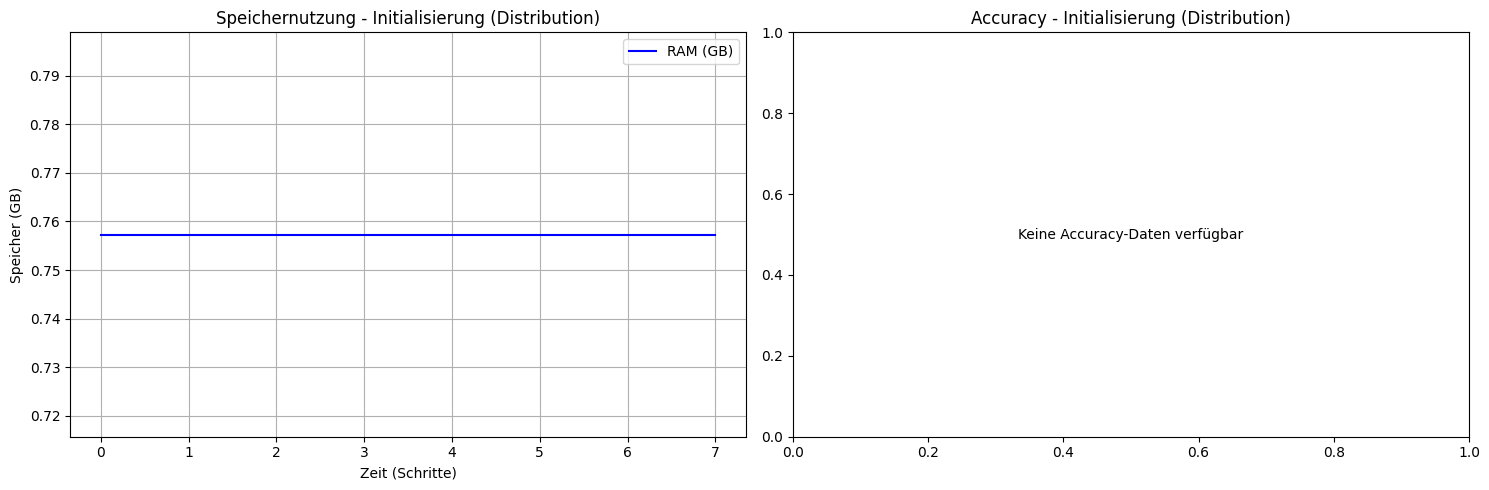

0

In [49]:
monitor.run_command(
        [
            "python", "../sisa-fork/distribution.py",
            "--shards", "10",
            "--container", CONTAINER_NAME,
            "--dataset", DATAFILEPATH,
            "--label", LABEL
        ],
        description="Initialisierung (Distribution)"
    )

In [116]:
#Initialisierung
init=subprocess.run([
    "python", "../sisa-fork/distribution.py",
    "--shards",str(NUM_SHARDS),
    "--container", CONTAINER_NAME,
    "--dataset", DATAFILEPATH,
    "--label", LABEL
],
capture_output=True,  # Fängt stdout und stderr ab
text=True             # Gibt die Ausgabe als Text zurück
)
print("STDOUT:", init.stdout)
print("STDERR:", init.stderr)
print("Returncode:", init.returncode)

STDOUT: 
STDERR: 
Returncode: 0


In [25]:
# Überprüfung splitfile.npy
splitfile_path = f"{container_path}/splitfile.npy"
if os.path.exists(splitfile_path):
    shards = np.load(splitfile_path, allow_pickle=True)
    print(f"\nInhalt von splitfile.npy (Anzahl der Shards: {len(shards)}):")
    for i, shard in enumerate(shards):
        print(f"  Shard {i}: {len(shard)} Samples")


Inhalt von splitfile.npy (Anzahl der Shards: 10):
  Shard 0: 5000 Samples
  Shard 1: 5000 Samples
  Shard 2: 5000 Samples
  Shard 3: 5000 Samples
  Shard 4: 5000 Samples
  Shard 5: 5000 Samples
  Shard 6: 5000 Samples
  Shard 7: 5000 Samples
  Shard 8: 5000 Samples
  Shard 9: 5000 Samples


In [26]:
#Jetzt 2 dateien erstellt
#splitfile.npy:  Eine Liste vonEine Liste von NumPy-Arrays, wobei jedes Array die Indizes der zu löschenden Daten für einen Shard enthält NumPy-Arrays, wobei jedes Array die Indizes der Trainingsdaten für einen Shard enthält
#requestfile:<label>.npy: Eine Liste von NumPy-Arrays, wobei jedes Array die Indizes der zu löschenden Daten für einen Shard enthält -> Hier Initiales Training,also Datei leer

In [74]:
# Training
#alle Arumente als Strings, da subprocess das so braucht
for i in range(NUM_SHARDS):
    print(f"Training Shard {i+1}/{NUM_SHARDS}...")
    train_all=subprocess.run([
        "python", "../sisa/sisa-fork/sisa.py",
        "--model", MODEL_NAME,
        "--train",
        "--slices", str(NUM_SLICES),
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--epochs", str(EPOCHS),
        "--batch_size", str(BATCH_SIZE),
        "--learning_rate", str(LEARNING_RATE),
        "--optimizer", OPTIMIZER,
        "--chkpt_interval", "1",
        "--container", CONTAINER_NAME,
        "--shard", str(i)
    ],
capture_output=True,  # Fängt stdout und stderr ab
text=True             # Gibt die Ausgabe als Text zurück
)
print(f"Ouput of Traing shard {i+1}/{NUM_SHARDS}")
print("STDOUT:", train_all.stdout)
print("STDERR:", train_all.stderr)
print("Returncode:", train_all.returncode)

Training Shard 1/10...
Training Shard 2/10...
Training Shard 3/10...
Training Shard 4/10...
Training Shard 5/10...
Training Shard 6/10...
Training Shard 7/10...
Training Shard 8/10...
Training Shard 9/10...
Training Shard 10/10...
Ouput of Traing shard 10/10
STDOUT: 
STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Traceback (most recent call last):
  File "C:\Users\sophi\OneDrive\Documents\TH\Bachelorarbeit\Code\notebooks\sisa\sisa-fork\sisa.py", line 186, in <module>
    for images, labels in fetchShardBatch(
  File "C:\Users\sophi\OneDrive\Documents\TH\Bachelorarbeit\Code\notebooks\sisa\sisa-fork\sharded.py", line 48, in fetchShardBatch
    dataloader = importlib.import_module('.'.join(dataset.split('/')[:-1] + [datasetfile


Training (Shard 0)


STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
STDERR: warnings.warn(msg)



Ressourcenbericht für 'Training (Shard 0)':
  - training_time_sec: 13.02
  - peak_ram_gb: 0.76
  - gpu_used: False
  - peak_gpu_gb: 0
  - accuracy_history: 0 Werte
  - val_accuracy_history: 0 Werte


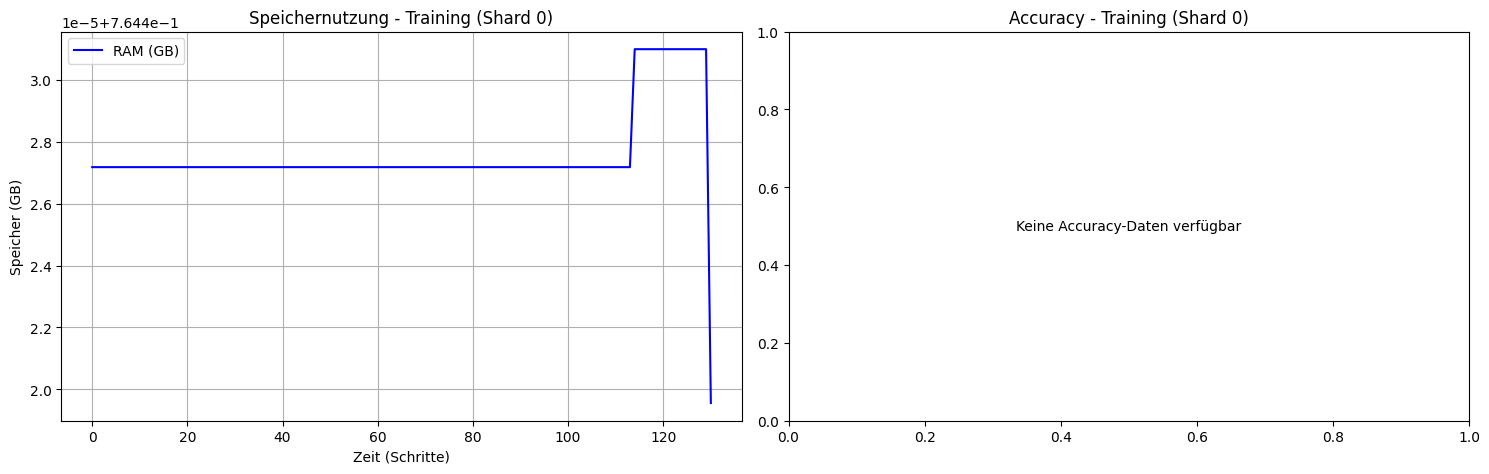

0

In [51]:
# 2. Training
monitor.run_command(
    [
        "python", "../sisa-fork/sisa.py",
        "--model", "resnet18",
        "--train",
        "--slices", "1",
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--epochs", "1",
        "--batch_size", "64",
        "--learning_rate", "0.001",
        "--optimizer", "adam",
        "--container", CONTAINER_NAME,
        "--shard", "0"
    ],
    description="Training (Shard 0)"
)


Vorhersage (Shard 0)


STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
STDERR: warnings.warn(msg)
STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
STDERR: I0000 00:00:1782820958.889143   18880 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
STDERR: I0000 00:00:1782820968.127903   18880 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computa

x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000

Ressourcenbericht für 'Vorhersage (Shard 0)':
  - training_time_sec: 142.01
  - peak_ram_gb: 0.77
  - gpu_used: False
  - peak_gpu_gb: 0
  - accuracy_history: 0 Werte
  - val_accuracy_history: 0 Werte


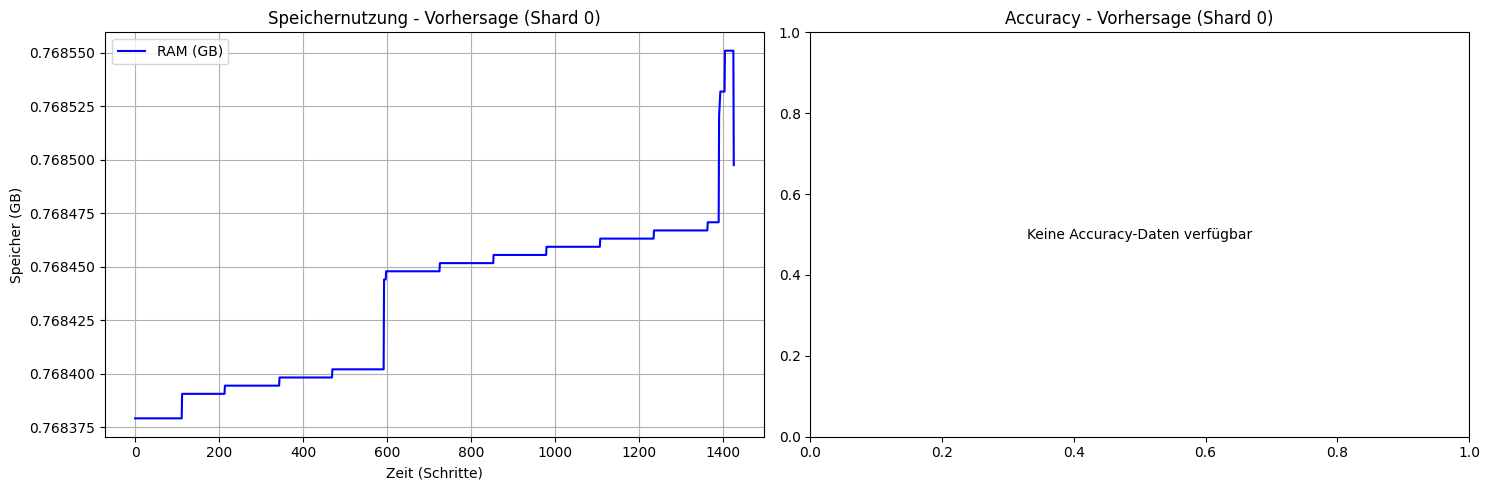

0

In [52]:
# 3. Vorhersage
monitor.run_command(
    [
        "python", "../sisa-fork/sisa.py",
        "--model", "resnet18",
        "--test",
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--batch_size", "64",
        "--container", CONTAINER_NAME,
        "--shard", "0"
    ],
    description="Vorhersage (Shard 0)"
)

In [119]:
#Prüfen ob Training funktioniert hat
result=subprocess.run([
    "python", r"../sisa-fork/sisa.py",  # Rohstring für den Pfad
     "--model", MODEL_NAME,
        "--train",
        "--slices", str(NUM_SLICES),
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--epochs", "1", #str(EPOCHS)
        "--batch_size", str(BATCH_SIZE),
        "--learning_rate", str(LEARNING_RATE),
        "--optimizer", OPTIMIZER,
        "--chkpt_interval", "1",
        "--container", CONTAINER_NAME,
        "--shard", "0"
],
capture_output=True,  # Fängt stdout und stderr ab
text=True             # Gibt die Ausgabe als Text zurück
)
# Gib die Standardausgabe und Fehlerausgabe aus
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Returncode:", result.returncode)

STDOUT: x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000

STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
I0000 00:00:1782664120.885527   12368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782664126.354561   12368 port.cc:153] oneDNN custom operations are on. You may see slightly different nu

In [122]:
import torch

# Lade das gespeicherte Modell
checkpoint = torch.load(f"containers/{CONTAINER_NAME}/cache/shard-0-0.pt", map_location=torch.device('cpu'))
print("Gespeicherte conv1.weight Form:", checkpoint['model.conv1.weight'].shape)
# Sollte torch.Size([64, 3, 3, 3]) sein!

Gespeicherte conv1.weight Form: torch.Size([64, 3, 3, 3])


In [123]:
cache_dir = "containers/Baseline/cache"
if os.path.exists(cache_dir):
    print(f"Inhalt von {cache_dir}:")
    for file in os.listdir(cache_dir):
        file_path = os.path.join(cache_dir, file)
        if os.path.isfile(file_path):
            size = os.path.getsize(file_path)
            print(f"  - {file} ({size} Bytes)")
        else:
            print(f"  - {file}/ (Ordner)")
else:
    print(f"❌ Ordner {cache_dir} existiert nicht!")

Inhalt von containers/Baseline/cache:
  - 374d7dbee26e7eaadb7198c0907d72453a22938a6c83ea8ba4030ee168dd0e39.pt (44783371 Bytes)
  - 86dd7f9ed59332d148e0de9c4c33b5aac445c31b5336019bcf43842d533e0e35.pt (44783371 Bytes)
  - f01299897823b1f8546c5c4474ba85be48658ec45fd6d7f509cb7e81681e0688.pt (44783371 Bytes)
  - f01a1d65590a792a9a96af113c53e1f0c97b5a641915821be3c2b1b6752aa070.pt (44783371 Bytes)
  - f71d1ca4dc8985bddcd756d0ed72a34c818441a92a9bb7d432333f8a98450bdd.pt (44783371 Bytes)
  - shard-0-0.pt (44783371 Bytes)


In [ ]:
# Vorhersagen
for i in range(NUM_SHARDS):
    print(f"Predicting with Shard {i+1}/{NUM_SHARDS}...")
    prediction_all=subprocess.run([
        "python", "../sisa-fork/sisa.py",
        "--model", MODEL_NAME,
        "--test", #Important
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--batch_size", str(BATCH_SIZE),
        "--container", CONTAINER_NAME,
        "--shard", str(i)
    ], 
capture_output=True, 
text=True)
print("STDOUT:", prediction_all.stdout)
print("STDERR:", prediction_all.stderr)
print("Returncode:", prediction_all.returncode)

In [124]:
#Prüfen ob Vorhersagen funktioniert
predict=subprocess.run([
    "python", "../sisa-fork/sisa.py",
    "--model", MODEL_NAME,
    "--test", #Important
    "--dataset", DATAFILEPATH,
    "--label", LABEL,
    "--batch_size", str(BATCH_SIZE),
    "--container", CONTAINER_NAME,
    "--shard", "0"
    ],
capture_output=True,  # Fängt stdout und stderr ab
text=True             # Gibt die Ausgabe als Text zurück
)
# Gib die Standardausgabe und Fehlerausgabe aus
print("STDOUT:", predict.stdout)
print("STDERR:", predict.stderr)
print("Returncode:", predict.returncode)

STDOUT: x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000

STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
I0000 00:00:1782664334.167436   18404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782664338.576745   18404 port.cc:153] oneDNN custom operations are on. You may see slightly different nu


🔄 Aggregation (alle Shards)


STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
STDERR: I0000 00:00:1782821113.691362   22944 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
STDERR: I0000 00:00:1782821123.858338   22944 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to

x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000
0.3532

Ressourcenbericht für '🔄 Aggregation (alle Shards)':
  - training_time_sec: 62.8
  - peak_ram_gb: 0.77
  - gpu_used: False
  - peak_gpu_gb: 0
  - accuracy_history: 1 Werte (z. B. [0.3532])
  - val_accuracy_history: 0 Werte


C:\Users\sophi\AppData\Local\Temp\ipykernel_21856\107225114.py:200: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


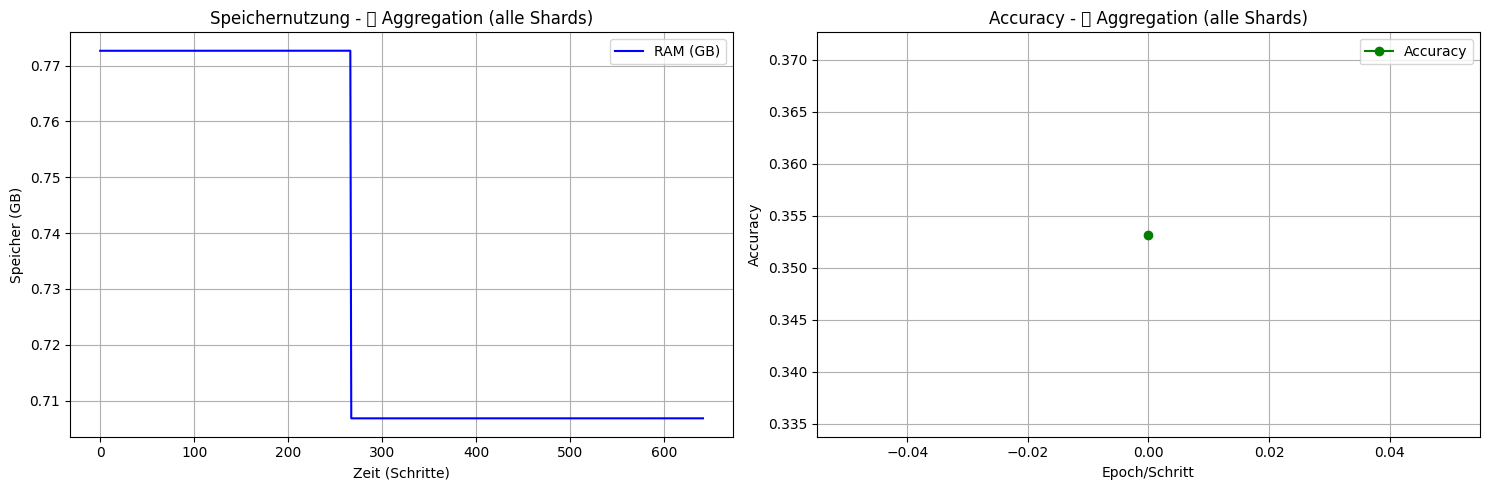

0

In [53]:
monitor.run_command(
        [
            "python", "../sisa-fork/aggregation.py",
            "--strategy", "uniform",
            "--container", CONTAINER_NAME,
            "--shards", "1",
            "--dataset", DATAFILEPATH,
            "--label", LABEL
        ],
        description="🔄 Aggregation (alle Shards)"
    )

In [125]:
#7. Aggregation 

aggregation = subprocess.run([
    "python", "../sisa-fork/aggregation.py",
    "--strategy", "uniform",
    "--container", CONTAINER_NAME,
    "--shards", "1", #str(NUM_SHARDS)
    "--dataset", DATAFILEPATH,
    "--label", LABEL
], 
capture_output=True, 
text=True)
print("STDOUT:", aggregation.stdout)
print("STDERR:", aggregation.stderr)
print("Returncode:", aggregation.returncode)

STDOUT: x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000
0.3532

STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1782664421.967937   29352 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782664426.385730   29352 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
C:\Users\sophi\miniconda3\envs\thesis\Lib\site-

In [30]:
# Lade Vorhersagen aller Shards
outputs = []
for i in range(1): #NUM_SHARDS
    pred_file = f"../sisa-fork/containers/{CONTAINER_NAME}/outputs/shard-{i}-{LABEL}.npy"
    pred = np.load(pred_file)
    outputs.append(pred)
outputs = np.array(outputs)

In [32]:
# Lade die Vorhersagen für Shard 0
predictions = np.load("containers/Baseline/outputs/shard-0-0.npy")
print("Form der Vorhersagen:", predictions.shape)  # Sollte (10000, 10) sein (10000 Testbilder, 10 Klassen)
print("Beispiel-Vorhersagen (erste 5):\n", predictions[:5])  # Sollte Wahrscheinlichkeiten oder Logits sein

Form der Vorhersagen: (10000, 10)
Beispiel-Vorhersagen (erste 5):
 [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]


In [58]:
#Eval on Datasets
print("\n" + "="*50)
print("Evaluation des fertigen Modells")
print("="*50)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Lade das Modell
from architectures.resnet18 import Model
model = Model(input_shape=(3, 32, 32), nb_classes=10).to(device)

# Lade das trainierte Modell
model_path = f"containers/{CONTAINER_NAME}/cache/shard-0-0.pt"
if os.path.exists(model_path):
    try:
        # Lade das state_dict (mit korrektem Schlüssel)
        checkpoint = torch.load(model_path, map_location=device)
        # Falls das Modell in einer 'model'-Klasse gespeichert ist:
        if 'model.conv1.weight' in checkpoint:
            # Erstelle ein Dummy-Modell, um die Architektur zu laden
            dummy_model = Model(input_shape=(3, 32, 32), nb_classes=10)
            dummy_model.load_state_dict(checkpoint, strict=False)
            model = dummy_model.to(device)
        else:
            model.load_state_dict(checkpoint, strict=False)
        print(f"Modell geladen: {model_path}")
    except Exception as e:
        print(f"Fehler beim Laden des Modells: {e}")
        sys.exit(1)
else:
    print(f"Modell nicht gefunden: {model_path}")
    sys.exit(1)

# Lade den Test-Datensatz
from datasets.CIFAR10.dataloader_all_data import load
test_indices = np.arange(10000)  # Alle Testdaten
X_test, y_test = load(test_indices, category='test')

# Erstelle einen DataLoader
from torch.utils.data import TensorDataset, DataLoader
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Evaluiere das Modell
evaluate_model(model, test_loader, device, model_name=f"Shard 0 (Label {LABEL})")

# 6. Zeige an, welche Shards von Unlearning betroffen sind
requestfile_path = f"containers/{CONTAINER_NAME}/requestfile-{LABEL}.npy"
if os.path.exists(requestfile_path):
    requests = np.load(requestfile_path)
    print(f"\nShards mit Unlearning-Requests (Label {LABEL}):")
    for i, req in enumerate(requests):
        if req.size > 0:
            print(f"  - Shard {i}: {req} Datenpunkte entfernen")
else:
    print(f"\nKeine Unlearning-Requests gefunden für Label {LABEL}")


Evaluation des fertigen Modells


C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Modell geladen: containers/Baseline/cache/shard-0-0.pt

Evaluation for Shard 0 (Label 0)
Accuracy: 0.2844
Precision: 0.3308
Recall: 0.2844
F1 Score: 0.2478
\Classification Report:
              precision    recall  f1-score   support

    Flugzeug       0.25      0.79      0.37      1000
        Auto       0.52      0.08      0.14      1000
       Vogel       0.28      0.08      0.13      1000
       Katze       0.23      0.17      0.19      1000
      Hirsch       0.30      0.50      0.38      1000
        Hund       0.27      0.07      0.10      1000
      Frosch       0.25      0.51      0.34      1000
       Pferd       0.40      0.26      0.31      1000
      Schiff       0.33      0.23      0.27      1000
         LKW       0.48      0.15      0.23      1000

    accuracy                           0.28     10000
   macro avg       0.33      0.28      0.25     10000
weighted avg       0.33      0.28      0.25     10000


🔍 Confusion Matrix (mit Klassennamen):
           |  Flugzeu

In [ ]:
# Unlearning

In [126]:
#Requests manuell vorbereiten
# Pfad zur requestfile
requestfile_path = f"containers/{CONTAINER_NAME}/requestfile-{LABEL}.npy"

# Erstelle die requestfile basierend Dateien -> Loeschszenarios
forget_indices = np.load(r"C:\Users\sophi\OneDrive\Documents\TH\Bachelorarbeit\Code\notebooks\data\cifar10_split10\x_delete10.npy")  # Indizes der zu löschenden Datenpunkte
NUM_SHARDS = 10  

# Berechne die Anzahl der zu löschenden Datenpunkte pro Shard
forget_per_shard = len(forget_indices) // NUM_SHARDS
requests = np.full((NUM_SHARDS,), forget_per_shard, dtype=int)

# Speichere die requestfile
os.makedirs(os.path.dirname(requestfile_path), exist_ok=True)
np.save(requestfile_path, requests)

print(f"✅ Unlearning-Request direkt erstellt: {requestfile_path}")
print(f"Inhalt: {requests}")

✅ Unlearning-Request direkt erstellt: containers/Baseline/requestfile-0.npy
Inhalt: [500 500 500 500 500 500 500 500 500 500]


In [127]:
# Überprüfung requestfile-0.npy
requestfile_path = f"{container_path}/requestfile-0.npy"
if os.path.exists(requestfile_path):
    requests = np.load(requestfile_path, allow_pickle=True)
    print(f"\nInhalt von requestfile:0.npy (Anzahl der Shards: {len(requests)}):")
    for i, req in enumerate(requests):
        print(f"  Shard {i}: {req} Requests")


Inhalt von requestfile:0.npy (Anzahl der Shards: 10):
  Shard 0: 500 Requests
  Shard 1: 500 Requests
  Shard 2: 500 Requests
  Shard 3: 500 Requests
  Shard 4: 500 Requests
  Shard 5: 500 Requests
  Shard 6: 500 Requests
  Shard 7: 500 Requests
  Shard 8: 500 Requests
  Shard 9: 500 Requests


In [65]:
# Generiere Requests
#Ich habe schon vorbereitete Datensaetze -> Basis der Requests
#TODO: weg finden, datei direkt zu nehmen
#Kann nicht benutzt werden, da custom Datenpunkte nicht möglich


#unlearning_requests=subprocess.run([
#    "python", "../sisa-fork/distribution.py",
#    "--requests", 




In [50]:
# Trainiere betroffenen Shards neu
#Hier grade alle Shards aber das schlecht
for i in range(shards):
    print(f"Retraining Shard {i+1}/{shards} with Unlearning...")
    retrain_all=subprocess.run([
        "python", "../sisa-fork/sisa.py",
        "--model", MODEL_NAME,
        "--train",
        "--slices", "1",
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--epochs", str(EPOCHS),
        "--batch_size", str(BATCH_SIZE),
        "--learning_rate", str(LEARNING_RATE),
        "--optimizer", OPTIMIZER,
        "--chkpt_interval", "1",
        "--container", CONTAINER_NAME,
        "--shard", str(i)
    ], 
capture_output=True, 
text=True)
print("STDOUT:", retrain_all.stdout)
print("STDERR:", retrain_all.stderr)
print("Returncode:", retrain_all.returncode)


TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
#TODO: symfile loeschen

In [129]:
#Prüfen ob Training funktioniert hat
result=subprocess.run([
    "python", r"../sisa-fork/sisa.py",  # Rohstring für den Pfad
     "--model", MODEL_NAME,
        "--train",
        "--slices", str(NUM_SLICES),
        "--dataset",  DATAFILEPATH,
        "--label", LABEL,
        "--epochs", "1", #str(EPOCHS)
        "--batch_size", str(BATCH_SIZE),
        "--learning_rate", str(LEARNING_RATE),
        "--optimizer", OPTIMIZER,
        "--chkpt_interval", "1",
        "--container", CONTAINER_NAME,
        "--shard", "0"
],
capture_output=True,  # Fängt stdout und stderr ab
text=True             # Gibt die Ausgabe als Text zurück
)
# Gib die Standardausgabe und Fehlerausgabe aus
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Returncode:", result.returncode)

STDOUT: 
STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)

Returncode: 0


In [104]:
# Berechne Vorhersagen für Unlearning
for i in range(shards):
    prediction_unlearning=subprocess.run([
        "python", "../sisa-fork/sisa.py",
        "--model",MODEL_NAME,
        "--test",
        "--dataset", DATAFILEPATH,
        "--label", LABEL,
        "--batch_size", str(BATCH_SIZE),
        "--container", CONTAINER_NAME,
        "--shard", str(i)
    ], 
capture_output=True, 
text=True)
print("STDOUT:", prediction_unlearning.stdout)
print("STDERR:", prediction_unlearning.stderr)
print("Returncode:", prediction_unlearning.returncode)

TypeError: only integer scalar arrays can be converted to a scalar index

In [130]:
predict=subprocess.run([
    "python", "../sisa-fork/sisa.py",
    "--model", MODEL_NAME,
    "--test", #Important
    "--dataset", DATAFILEPATH,
    "--label", LABEL,
    "--batch_size", str(BATCH_SIZE),
    "--container", CONTAINER_NAME,
    "--shard", "0"
    ],
capture_output=True,  # Fängt stdout und stderr ab
text=True             # Gibt die Ausgabe als Text zurück
)
# Gib die Standardausgabe und Fehlerausgabe aus
print("STDOUT:", predict.stdout)
print("STDERR:", predict.stderr)
print("Returncode:", predict.returncode)

STDOUT: x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000

STDERR: C:\Users\sophi\miniconda3\envs\thesis\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
I0000 00:00:1782664636.175109   25284 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782664640.543718   25284 port.cc:153] oneDNN custom operations are on. You may see slightly different nu

In [131]:
# Aggregiere Vorhersagen

aggregation_unlearn = subprocess.run([
    "python", "../sisa-fork/aggregation.py",
    "--strategy", "uniform",
    "--container", CONTAINER_NAME,
    "--shards", "1", #str(NUM_SHARDS)
    "--dataset", DATAFILEPATH,
    "--label",  LABEL
], 
capture_output=True, 
text=True)
print("STDOUT:", aggregation_unlearn.stdout)
print("STDERR:", aggregation_unlearn.stderr)
print("Returncode:", aggregation_unlearn.returncode)




STDOUT: x_train shape: (45000, 32, 32, 3)
y_train shape: (45000, 1)
x_val shape: (5000, 32, 32, 3)
y_val shape: (5000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Number of training datapoints: 45000
Number of validation datapoints: 5000
Number of test datapoints: 10000
0.3566

STDERR: WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1782664733.692957   30820 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782664738.301572   30820 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
C:\Users\sophi\miniconda3\envs\thesis\Lib\site-